# Where a ground state starts: every Potts solver on a 50x50 lattice, polished by ICM

Every ground-state solver of `search.ground_state` (issue #906), each run as a
start of the one seam `opt.starts.StartsBenchmark` (#894), each polished by the
same descent, iterated conditional modes to a local minimum, and each read
against what can referee an energy at this size. The counterpart of
`emission_mixture_starts.ipynb` on a lattice: there a start seeds EM, here a
solver's labelling seeds ICM.

Four terms the rest uses:

- The **energy** is `sim.potts.energy`, `-sum_n h[n, x_n] - J sum_(n,m) [x_n = x_m]`,
  lower being better; a **gap** is an energy less the reference, in the
  energy's own units.
- A **`Budget`** (`opt.budget.Budget`) is a ceiling in a stated unit. Each
  solver spends `SWEEPS` heat-bath sweeps' worth of **site visits**, the unit
  `search.ground_state` bills every solver in, so a cluster move pays for the
  sites it touches; the polish spends **sweeps** of ICM until one changes
  nothing; and every (solver, seed) cell is held to `Budget(Cost.SECONDS, 120)`
  of wall clock, checked on the cells' own clocks.
- The **polish** is `search.potts_starts.polish_by_icm`: one index-order ICM
  sweep at a time from the solver's labelling, stopping at the first sweep that
  changes nothing. What separates two solvers is where they leave the labelling.
- The **seam** is `opt.starts.StartsBenchmark`, entered through
  `search.potts_starts`: the energy as an `Objective` whose `theta` is the
  labelling, a solver as an `Initializer`, ICM as a `Polisher`.

The instance is `potts_lattice/release`: an open 50x50 square, 2,500 sites, at
`q = 3` and the exact critical coupling, in a field tilted by each site's
lognormal size over the class ladder (-1, 0, 1). At `q = 3` no exact optimum is
known at 2,500 sites, so the energy is read against the **alpha-expansion
bracket**: the expansion's own energy, which the optimum is at most, and the
lower end its factor-2 bound gives. The same lattice and sizes at `q = 2`, the
ladder's ends, has an **exact** ground state by graph cut, and is run beside it
for one exact gap. The second referee is the **structure** of the parameters
that built the field: the size tilt, the null class and the occupancy.

In [1]:
import functools
import os
import time

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Math, display
from snakes_and_ladders.cost import Cost
from snakes_and_ladders.opt.budget import Budget
from snakes_and_ladders.opt.starts import StartsBenchmark
from snakes_and_ladders.qa.starts import gap_table
from snakes_and_ladders.qa.style import notebook_style
from snakes_and_ladders.search.ground_state import (
    ANNEAL_END,
    ANNEAL_START,
    METHODS,
    N_REPLICAS,
    expansion_bracket,
    run_alpha_expansion,
    structure,
)
from snakes_and_ladders.search.potts_starts import (
    PottsObjective,
    SolverStart,
    binary_sibling,
    describe,
    polish_by_icm,
    rung_of,
)
from snakes_and_ladders.sim.fixtures import fixture

np.set_printoptions(precision=3, suppress=True)

## The instance, and the references its energies are read against

`fixture` reads the declared file, and `search.potts_starts.rung_of` builds the
rung from it; `binary_sibling` keeps the lattice and the sizes and takes the
ladder's two ends, and carries its graph-cut optimum. Alpha-expansion is run
once at the solvers' budget for the bracket.

In [2]:
#: Heat-bath sweeps' worth of site visits each solver may spend.
SWEEPS = 1000

# The declared instance: tests/regression/fixtures/potts_lattice/release.yaml.
declared = fixture("potts_lattice", "release").params
# The three-state rung, with its ladder and sizes for the structural referee.
rung = rung_of(declared, "release-q3")
# The same lattice and sizes at two states, with its exact optimum by graph cut.
sibling = binary_sibling(rung, "release-q2")
# Each rung's solver budget, in the site visits its own sweeps cost.
SOLVER_BUDGET = {
    r.name: Budget(Cost.SITE_VISITS, SWEEPS * r.visits_per_sweep)
    for r in (rung, sibling)
}
# The expansion's energy at q = 3 and the bracket its factor-2 bound gives.
expansion = run_alpha_expansion(
    rung, SOLVER_BUDGET[rung.name], np.random.default_rng(0)
).energy
bracket = expansion_bracket(rung, expansion)
# Each rung's reference: the expansion's energy at q = 3, the exact optimum at q = 2.
REFERENCE = {rung.name: expansion, sibling.name: sibling.optimum}
print(
    f"{rung.n_nodes} sites, {len(rung.graph.edges)} edges, q = {rung.n_states}, "
    f"J = {declared.coupling:.4f}"
)
print(
    f"q = 3: expansion {expansion:.2f}, bracket [{bracket.lower:.2f}, {bracket.upper:.2f}]"
)
print(f"q = 2: exact optimum by graph cut {sibling.optimum:.2f}")

2500 sites, 4900 edges, q = 3, J = 1.0051
q = 3: expansion -4997.93, bracket [-5558.57, -4997.93]
q = 2: exact optimum by graph cut -4997.93


## The solvers

Each solver's description is the first paragraph of its own docstring in
`search.ground_state`, so the text cannot drift from the code. Every solver
spends `SWEEPS` sweeps' worth of site visits: the annealed ones from
`ANNEAL_START` to `ANNEAL_END`, tempering over `N_REPLICAS` rungs of the same
range, the graph-cut moves and belief propagation until they settle or the
visits run out.

In [3]:
ORDER = list(METHODS)
print(
    f"anneal from {ANNEAL_START} to {ANNEAL_END}; tempering over {N_REPLICAS} "
    f"replicas; {SWEEPS} sweeps = {SOLVER_BUDGET[rung.name].size:,} site visits at q = 3"
)
for name in ORDER:
    # Each solver's own docstring, its first paragraph, and the move it fixes.
    print(f"{name:16s} {describe(name)}")

anneal from 2.0 to 0.05; tempering over 6 replicas; 1000 sweeps = 12,300,000 site visits at q = 3
greedy           The field-only labelling: every site takes its own best class, coupling ignored.
icm              Iterated conditional modes: single-site descent in index order.
gibbs-T0         Gibbs at T = 0 in a random sweep order, which is ICM under a permutation.
anneal           One annealed run, its step count fixed before the run starts. Move set: single-site.
swendsen-wang    One annealed run, its step count fixed before the run starts. Move set: swendsen-wang.
wolff            One annealed run, its step count fixed before the run starts. Move set: wolff.
tempering        Parallel tempering over a geometric ladder, charged for every replica.
alpha-expansion  Alpha expansion: the only entry carrying a bound, and the bracket's lower end.
alpha-beta-swap  Alpha-beta swap: the cheaper move, and the one with no bound.
max-product      Max-product on the factor graph: MAP-exact on a tr

## Every solver, five seeds, both rungs

`StartsBenchmark` runs each (solver, seed) cell on a pool of four worker
processes, each cell drawing from `default_rng([seed, instance])`; every
solver reads its generator, and the deterministic ones (greedy, the graph-cut
moves, belief propagation) return the same labelling at every seed. The
seeding budget is one evaluation, the solver's one labelling; the polish's is
a cap of `POLISH` sweeps it does not reach.

In [4]:
#: Seeds of every cell.
SEEDS = [0, 1, 2, 3, 4]
#: Cells run at once, one worker process per core of the 4-core host.
WORKERS = 4
#: ICM's cap, in sweeps; every polish here stops on a clean sweep first.
POLISH = Budget(Cost.SWEEPS, 200)
#: The wall clock any one cell may take.
CEILING = Budget(Cost.SECONDS, 120)

load_before = os.getloadavg()
opened = time.perf_counter()
results = {}
for current in (rung, sibling):
    # Every solver as a start on this rung, built per cell from its generator.
    starts = {
        name: functools.partial(SolverStart, name, SOLVER_BUDGET[current.name])
        for name in ORDER
    }
    results[current.name] = StartsBenchmark(
        PottsObjective(current),
        starts,
        polish_by_icm,
        seeding_budget=Budget(Cost.EVALUATIONS, 1),
        polish_budget=POLISH,
        seeds=SEEDS,
        workers=WORKERS,
        reference=[REFERENCE[current.name]],
    ).run()
elapsed = time.perf_counter() - opened
load_after = os.getloadavg()

# Every cell's whole seconds, held to the ceiling.
longest = max(
    trial.seconds[-1]
    for result in results.values()
    for name in ORDER
    for trial in result.trials(name)
)
cells = sum(len(result.trials(name)) for result in results.values() for name in ORDER)
print(f"{cells} cells of {len(ORDER)} solvers on 2 rungs at {len(SEEDS)} seeds")

110 cells of 11 solvers on 2 rungs at 5 seeds


## What each solver handed over, and where ICM left it

Per rung and solver, over the five seeds: the energy the solver handed over
and its gap, the gap where ICM stopped, the ICM sweeps, and how many seeds
ended on the reference exactly. At `q = 3` the gap is above the expansion's
energy, which is not the optimum, so a negative gap is a labelling below the
expansion and inside the bracket; at `q = 2` it is above the exact optimum and
cannot be negative. Energies and gaps are continuous in the seeds, and this
cell is compared.

In [5]:
def spread(values: list[float], digits: int = 2) -> str:
    # The mean, and the sample standard deviation beside it over the seeds.
    return f"{np.mean(values):.{digits}f} ± {np.std(values, ddof=1):.{digits}f}"


for current in (rung, sibling):
    result = results[current.name]
    reference = REFERENCE[current.name]
    print(f"{current.name}: reference {reference:.2f}")
    print(
        "| solver | handed over | init. gap | final gap | ICM sweeps | at reference |"
    )
    print("|---|---|---|---|---|---|")
    for name in ORDER:
        trials = result.trials(name)
        print(
            f"| {name} | {spread([t.seeded_value for t in trials])} "
            f"| {spread([t.seeded_value - reference for t in trials])} "
            f"| {spread([t.value - reference for t in trials])} "
            f"| {spread([float(t.termination.iterations) for t in trials], 1)} "
            f"| {sum(abs(t.value - reference) < 1e-9 for t in trials)}/{len(trials)} |"
        )
    print()

release-q3: reference -4997.93
| solver | handed over | init. gap | final gap | ICM sweeps | at reference |
|---|---|---|---|---|---|
| greedy | -3701.05 ± 0.00 | 1296.88 ± 0.00 | 278.53 ± 0.00 | 6.0 ± 0.0 | 0/5 |
| icm | -4464.11 ± 36.05 | 533.82 ± 36.05 | 533.82 ± 36.05 | 1.0 ± 0.0 | 0/5 |
| gibbs-T0 | -4343.65 ± 22.96 | 654.28 ± 22.96 | 654.28 ± 22.96 | 1.0 ± 0.0 | 0/5 |
| anneal | -4978.22 ± 4.67 | 19.70 ± 4.67 | 19.61 ± 4.75 | 1.4 ± 0.5 | 0/5 |
| swendsen-wang | -4863.21 ± 13.81 | 134.72 ± 13.81 | 85.72 ± 8.49 | 4.4 ± 1.7 | 0/5 |
| wolff | -3187.97 ± 76.19 | 1809.96 ± 76.19 | 250.82 ± 27.02 | 6.0 ± 0.7 | 0/5 |
| tempering | -4895.60 ± 10.57 | 102.33 ± 10.57 | 99.92 ± 12.41 | 2.2 ± 1.1 | 0/5 |
| alpha-expansion | -4997.93 ± 0.00 | 0.00 ± 0.00 | 0.00 ± 0.00 | 1.0 ± 0.0 | 5/5 |
| alpha-beta-swap | -4997.93 ± 0.00 | 0.00 ± 0.00 | 0.00 ± 0.00 | 1.0 ± 0.0 | 5/5 |
| max-product | -4966.13 ± 0.00 | 31.79 ± 0.00 | 31.79 ± 0.00 | 1.0 ± 0.0 | 0/5 |
| bifurcation | -4884.88 ± 26.46 | 113.05 ±

## The structure the parameters say a ground state has

`search.ground_state.structure` reads a labelling against the ladder and the
sizes that built the field: the **tilt**, the mean class value of the largest
size quartile less the smallest's; the **null tilt**, the same for the class
whose value is zero, which carries no field anywhere; whether the mean rises
across all four quartiles; and the sites per class. Read at each solver's
polished labelling, seed 0, at `q = 3`, beside the expansion's.

In [6]:
print("| solver | tilt | null tilt | monotone | occupancy |")
print("|---|---|---|---|---|")
for name in ORDER:
    labelling = results[rung.name].trials(name)[0].theta.numpy()
    shape = structure(rung.alpha, rung.sizes, labelling)
    print(
        f"| {name} | {shape.tilt:.3f} | {shape.null_tilt:.3f} "
        f"| {shape.monotone} | {shape.occupancy} |"
    )

| solver | tilt | null tilt | monotone | occupancy |
|---|---|---|---|---|
| greedy | 1.014 | 0.000 | False | (1144, 0, 1356) |
| icm | 0.768 | -0.048 | True | (806, 500, 1194) |
| gibbs-T0 | 0.789 | -0.046 | True | (761, 722, 1017) |
| anneal | 0.701 | 0.000 | True | (1145, 0, 1355) |
| swendsen-wang | 0.797 | 0.000 | True | (1393, 0, 1107) |
| wolff | 0.651 | -0.030 | True | (993, 89, 1418) |
| tempering | 0.734 | 0.008 | True | (1364, 118, 1018) |
| alpha-expansion | 0.429 | 0.000 | True | (957, 0, 1543) |
| alpha-beta-swap | 0.429 | 0.000 | True | (957, 0, 1543) |
| max-product | 0.755 | 0.000 | True | (1214, 0, 1286) |
| bifurcation | 0.336 | 0.000 | False | (970, 288, 1242) |


## What it cost in seconds

The seconds are the host's, so this cell is tagged `host-dependent` and its
text is not compared (`docs/nb/README.md`). The table is
`qa.starts.gap_table`'s five columns per solver at `q = 3`: the gap and the
seconds at the handover and where ICM ended, mean ± std over the seeds, as
the LaTeX `tabular`, its caption and the `array` the notebook renders.

In [7]:
print(
    f"host: {os.cpu_count()} cores, {WORKERS} workers; 1-minute load "
    f"{load_before[0]:.2f} before and {load_after[0]:.2f} after; {cells} cells "
    f"took {elapsed:.0f} s, the longest cell {longest:.2f} s against the "
    f"{CEILING.size} s ceiling"
)
assert longest <= CEILING.size
tabular, caption, array = gap_table(results[rung.name], unit="energy")
print(tabular)
print()
print(caption)
display(Math(array))

host: 4 cores, 4 workers; 1-minute load 0.71 before and 2.73 after; 110 cells took 59 s, the longest cell 9.55 s against the 120 s ceiling
\begin{tabular}{lrrrr}
  \toprule
  initializer & init. gap [energy] & init time [s] & final gap [energy] & final time [s] \\
  \midrule
  \texttt{greedy} & 1296.88 $\pm$ 0.00 & 0.00 $\pm$ 0.00 & 278.53 $\pm$ 0.00 & 0.57 $\pm$ 0.32 \\
  \texttt{icm} & 533.82 $\pm$ 36.05 & 0.00 $\pm$ 0.00 & 533.82 $\pm$ 36.05 & 0.00 $\pm$ 0.00 \\
  \texttt{gibbs-T0} & 654.28 $\pm$ 22.96 & 8.58 $\pm$ 0.36 & 654.28 $\pm$ 22.96 & 8.58 $\pm$ 0.36 \\
  \texttt{anneal} & 19.70 $\pm$ 4.67 & 0.25 $\pm$ 0.01 & 19.61 $\pm$ 4.75 & 0.25 $\pm$ 0.01 \\
  \texttt{swendsen-wang} & 134.72 $\pm$ 13.81 & 9.44 $\pm$ 0.11 & 85.72 $\pm$ 8.49 & 9.44 $\pm$ 0.11 \\
  \texttt{wolff} & 1809.96 $\pm$ 76.19 & 0.65 $\pm$ 0.14 & 250.82 $\pm$ 27.02 & 0.65 $\pm$ 0.14 \\
  \texttt{tempering} & 102.33 $\pm$ 10.57 & 0.26 $\pm$ 0.03 & 99.92 $\pm$ 12.41 & 0.26 $\pm$ 0.03 \\
  \texttt{alpha-expansion} & 0

<IPython.core.display.Math object>

## Gap against runtime

Each solver's gap above the reference against the wall seconds from the cell's
opening, on a log axis: the mean over the seeds of each seed's gap held from
one sample to the next, with a band of one sample standard deviation either
side, and the diamond at the mean handover. Left the `q = 3` rung against the
expansion's energy, right the `q = 2` rung against the exact optimum. The gap
is plotted on a symmetric-log axis so the labellings below the expansion stay
on it. The x axis is a wall clock, so the cell is tagged `host-dependent`.

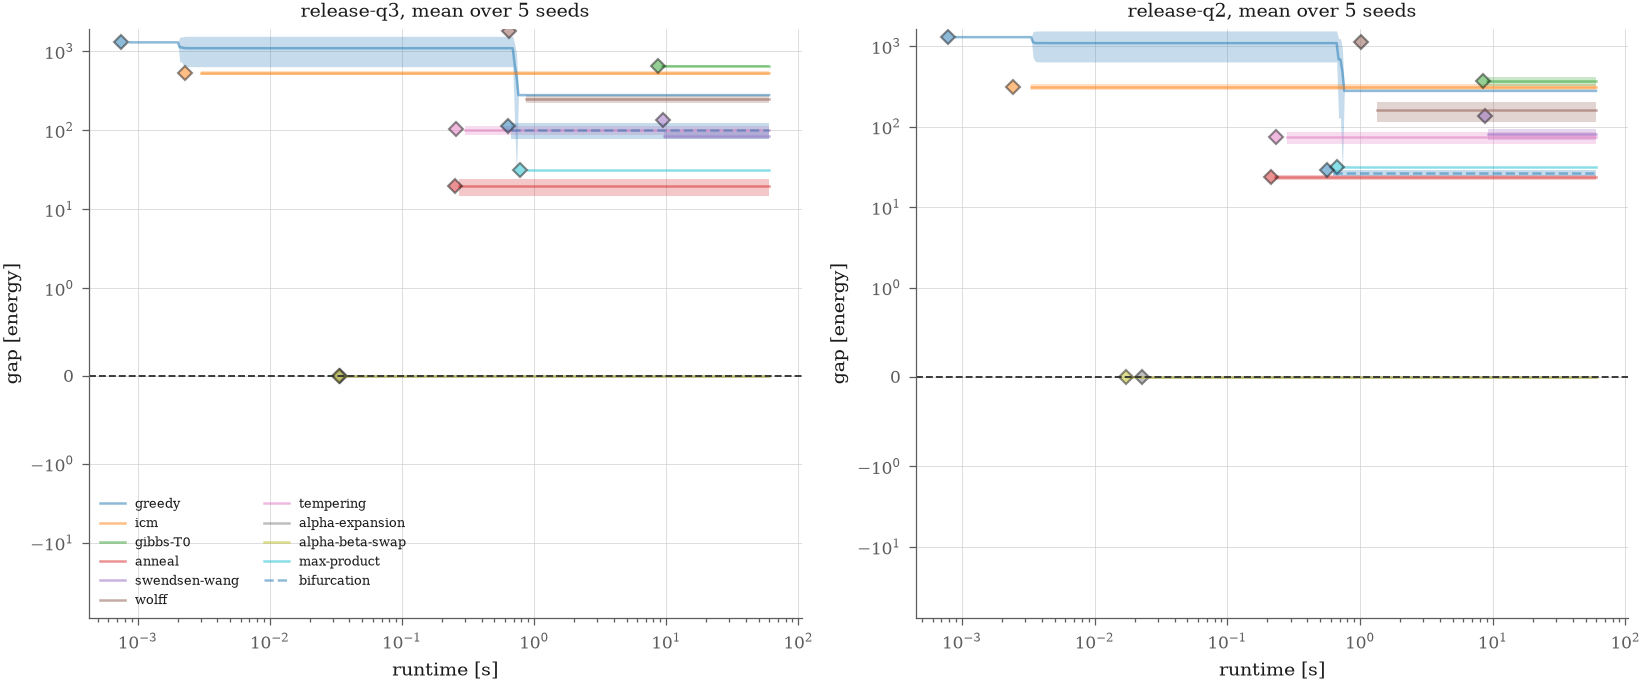

In [8]:
#: The log-spaced grid of seconds every seed is read on.
GRID = np.geomspace(1e-4, 60.0, 400)


def band(curves: tuple) -> tuple[np.ndarray, np.ndarray, float, float]:
    # Each seed's gap held from sample to sample on GRID; the mean and std over
    # seeds where every seed has a sample, and the mean handover point.
    held = np.full((len(curves), GRID.size), np.nan)
    for row, curve in enumerate(curves):
        index = np.searchsorted(curve.seconds, GRID, side="right") - 1
        held[row, index >= 0] = curve.gaps[index[index >= 0]]
    # Read only where every seed has a sample, so no column is empty.
    started = ~np.isnan(held).any(axis=0)
    mean = np.full(GRID.size, np.nan)
    std = np.full(GRID.size, np.nan)
    mean[started] = held[:, started].mean(axis=0)
    std[started] = held[:, started].std(axis=0, ddof=1)
    handed = [(c.seconds[c.handover], c.gaps[c.handover]) for c in curves]
    return mean, std, *np.mean(handed, axis=0)


with notebook_style():
    figure, axes = plt.subplots(1, 2, figsize=(11.0, 4.6), constrained_layout=True)
    for axis, current in zip(axes, (rung, sibling), strict=True):
        for index, (name, curves) in enumerate(results[current.name].curves().items()):
            mean, std, at_time, at_gap = band(curves)
            (line,) = axis.plot(
                GRID,
                mean,
                linewidth=1.2,
                alpha=0.5,
                linestyle="-" if index < 10 else "--",
                label=name,
            )
            axis.fill_between(
                GRID,
                mean - std,
                mean + std,
                color=line.get_color(),
                alpha=0.25,
                linewidth=0.0,
            )
            axis.plot(
                at_time,
                at_gap,
                marker="D",
                markersize=5,
                color=line.get_color(),
                markeredgecolor="0.1",
                alpha=0.5,
                linestyle="none",
            )
        axis.axhline(0.0, color="0.2", linewidth=0.9, linestyle="--")
        axis.set_xscale("log")
        axis.set_yscale("symlog", linthresh=1.0)
        axis.set_xlabel("runtime [s]")
        axis.set_ylabel("gap [energy]")
        axis.set_title(f"{current.name}, mean over {len(SEEDS)} seeds", fontsize=9)
    axes[0].legend(fontsize=6, ncol=2)
    plt.show()

## Read

**The graph cuts reach the exact two-state optimum at three states.**
Alpha-expansion and alpha-beta swap hand over -4,997.93 on every seed, the
graph-cut ground state of the `q = 2` sibling to the last digit shown, and their
labelling carries no site in the null class: 957 and 1,543 sites on the ladder's
ends. At `q = 3` the optimum is at most that and at least the bracket's
-5,558.57, so the three-state instance has not been shown to use its third
class at all; that is a finding about the instance, not about the solvers.

**Nothing else reaches it, before or after the polish.** Annealing ends 19.6 ±
4.8 above it at `q = 3` and 23.5 ± 1.8 at `q = 2`; max-product 31.8 on both;
parallel tempering and simulated bifurcation 100 at `q = 3`; Swendsen-Wang 85.7;
and Wolff, greedy, ICM and Gibbs at zero temperature 250 to 650. ICM moves an
annealed labelling by under a tenth and a Wolff or greedy one by 1,000 to 1,500:
where a solver leaves the labelling is what separates them.

**Wolff underspends its budget and this is where it shows.** Its annealed run
takes one cluster per step for as many steps as a heat-bath sweep budget buys
(`search.ground_state`), so it hands over 1,810 above the expansion at `q = 3`,
the worst of any solver, and ICM brings it to 251.

**The structure the parameters imply is read, not ranked.** Every solver but
greedy and bifurcation raises its mean class value across all four size
quartiles; the expansion's tilt is 0.43 against greedy's 1.01, the field-only
labelling that maximizes the tilt by construction, which is the trap the ground
state's coupling pays to leave. A thermal draw's tilt is the wrong referee for
a ground state (`search/ground_state.py`).

## Further work

- At `q = 3` the expansion's labelling uses no null-class site and equals the
  `q = 2` ground state; whether the three-state optimum lies below it needs a
  bound tighter than the factor-2 bracket, the plaquette dual of
  `search.tightening`: issue #920.
- The learned policy of `learn.potts` is not among the solvers; it has not been
  run at 2,500 sites: issue #920.
- The cluster moves' exactness in a per-site field is asserted by construction
  and not yet against enumeration, and Wolff's per-step adjacency copy is the
  cost at small clusters: issue #919.
- The solvers run at one budget in site visits; a sweep over the budget, where
  each first fails, is issue #596's.